Cauã Benini da Silva (RA )

Universidade Federal de São Carlos (UFSCar)

# Trabalho de Conclusão de Curso (TCC) - Aplicação dos Modelos


# Introdução

O objetivo deste trabalho é prever casos de hipotensão intradiálica em pacientes renais crônicos e posteriormente, adaptar estes modelos para um dashboard interativo a fim de simular sessões de hemodiálise e, com base em atributos demográficos e clínicos, prever se haverá ou não hipotensão durante a sessão.

Este trabalho se baseou no artigo *Predicting the Appearance of Hypotension during Hemodialysis Sessions Using Machine Learning Classifiers* (https://www.mdpi.com/1660-4601/18/5/2364#Abstract).

Abaixo, segue a importação das bibliotecas necessárias para esse desenvolvimento.

# Seleção do Dataset

Utilizou-se o dataset [*Dialysis database: sessions with valid data of clinical parameters*](https://data.mendeley.com/datasets/7kmtsmsgfw/1), disponibilizada pelos autores do artigo citado.

Este conjunto de dados foi coletado no Hospital Príncipe de Asturias (Madrid, Espanha) entre os anos de 2016 e 2019, abrangendo informações clínicas de 758 pacientes submetidos a tratamento de hemodiálise.

O dataset original contém aproximadamente 98.015 medições em sessões de hemodiálise, cada uma re-gistrada com até 22 parâmetros clínicos medidos em seis momentos distintos da sessão (Horas 0 a 5) - de forma com que cada 6 medições subsequentes correspondam a uma sessão de hemodiálise completa -, além de informações demográficas como idade e sexo dos pacientes. Entre
os parâmetros monitorados estão pressão arterial sistólica e diastólica, frequência cardíaca, peso pré e pós-diálise, volume de ultrafiltração, condutividade do banho de hemodiálise,
temperatura corporal, entre outros.

A identificação de episódios de hipotensão intradialítica foi realizada a partir da queda da pressão arterial sistólica maior ou igual a 20 mmHg entre os períodos iniciais e intermediários da sessão. Com base nesse critério, cerca de 25.026 sessões (aproximadamente 26% do total) apresentaram episódios de hipotensão, distribuídos entre 584 pacientes (77% da
amostra).


---

O autor forneceu 11 subcojuntos com múltiplas combinações de atributos válidos (cujas respectivas tuplas não possuem valores nulos ou com ouliers). Nesse caso, foi selecionado o subconjunto 7 da tabela a seguir, tendo em vista que os subconjuntos com mais atributos (8,9,10 e 11) apresentaram inconsistências em relação ao descrito pelo autor do dataset.

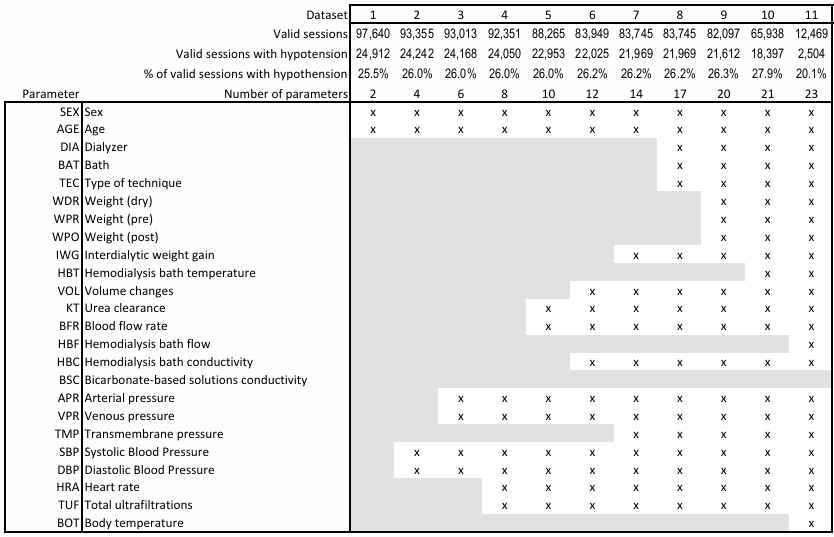

In [32]:
!pip install gdown pandas scikit-learn matplotlib xgboost 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import gdown

url = 'https://drive.google.com/uc?id=150jgnqblZ4yIRKvMP8vixDoZE3GPPEqA'
output = 'data/dataset_selected.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=150jgnqblZ4yIRKvMP8vixDoZE3GPPEqA
To: c:\Users\10142850\Desktop\TCC\data\dataset_selected.csv
100%|██████████| 17.3M/17.3M [00:04<00:00, 4.26MB/s]


'data/dataset_selected.csv'

In [34]:
# Transformar em Dataframe do Pandas e printar
import pandas as pd

df = pd.read_csv('data/dataset_selected.csv', sep=";", index_col=False)
df

,D_Hipotension,D_Sexo,D_Edad,D_Dializador,D_Bano,D_Tecnica,D_PesoSeco,D_PesoPre,D_PesoPost,D_Ganancia,...,D_ConductividadBano,D_ConductividadBicarbonato,D_PresionArterial,D_PresionVenosa,D_PTM,D_TAS,D_TAD,D_Pulso,D_UF,D_Temperatura
0,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
1,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
2,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
3,NO,1,69,8,1,1,69.0,70.0,68.6,1.0,...,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3
4,NO,1,69,8,1,1,69.0,70.0,69.0,1.2,...,13.7,0.0,-170.0,155.0,175.0,131.0,58.0,62.0,0.08,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,NO,1,82,1,15,0,71.0,73.3,70.9,1.9,...,13.3,0.0,-200.0,170.0,20.0,155.0,78.0,82.0,0.70,0.0
83741,NO,1,82,1,15,0,71.0,73.0,70.9,2.1,...,14.0,0.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59,0.0
83742,NO,1,82,1,15,0,71.0,73.7,71.1,2.8,...,13.7,0.0,-230.0,140.0,25.0,150.0,67.0,70.0,0.74,0.0
83743,NO,1,82,1,15,0,71.0,72.8,71.0,1.7,...,13.7,0.0,-200.0,155.0,15.0,129.0,60.0,83.0,0.51,0.0


# Preparação do Dataset

## 1. Tradução dos Atributos e Seleção dos Atributos Válidos

Para facilitar o entendimento, aplicou-se os mesmo nomes das colunas encontrados no artigo base neste dataset (já estavam na mesma ordem, apenas foram traduzidas para Espannhol).

Segue a tabela que mostra a descrição de cada um dos atributos:

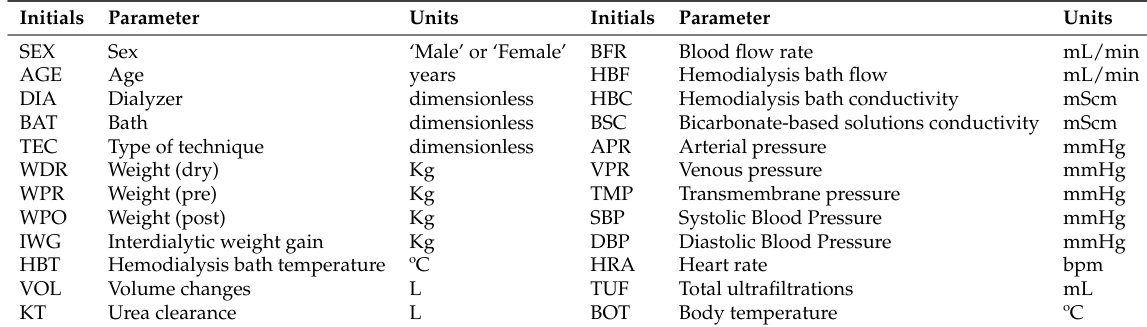


In [35]:
df.columns = ["Hypotension","SEX","AGE","DIA","BAT","TEC","WDR","WPR","WPO","IWG",
              "HBT","VOL","KT","BFR","HBF","HBC","BSC","APR","VPR","TMP",
              "SBP","DBP","HRA","TUF","BOT"]
df

,Hypotension,SEX,AGE,DIA,BAT,TEC,WDR,WPR,WPO,IWG,...,HBC,BSC,APR,VPR,TMP,SBP,DBP,HRA,TUF,BOT
0,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
1,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
2,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
3,NO,1,69,8,1,1,69.0,70.0,68.6,1.0,...,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3
4,NO,1,69,8,1,1,69.0,70.0,69.0,1.2,...,13.7,0.0,-170.0,155.0,175.0,131.0,58.0,62.0,0.08,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,NO,1,82,1,15,0,71.0,73.3,70.9,1.9,...,13.3,0.0,-200.0,170.0,20.0,155.0,78.0,82.0,0.70,0.0
83741,NO,1,82,1,15,0,71.0,73.0,70.9,2.1,...,14.0,0.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59,0.0
83742,NO,1,82,1,15,0,71.0,73.7,71.1,2.8,...,13.7,0.0,-230.0,140.0,25.0,150.0,67.0,70.0,0.74,0.0
83743,NO,1,82,1,15,0,71.0,72.8,71.0,1.7,...,13.7,0.0,-200.0,155.0,15.0,129.0,60.0,83.0,0.51,0.0


Em seguida, selecionou-se apenas os atributos válidos (sem valores nulos ou outliers), de acordo com a tabela da primeira seção.

In [36]:
colunas_validas = [
    'Hypotension', 'SEX', 'AGE',
    'IWG', 'VOL', 'KT', 'BFR',
    'HBC', 'APR', 'VPR',
    'TMP', 'SBP', 'DBP', 'HRA', 'TUF'
]
df = df[colunas_validas].copy()
df

,Hypotension,SEX,AGE,IWG,VOL,KT,BFR,HBC,APR,VPR,TMP,SBP,DBP,HRA,TUF
0,NO,1,69,0.0,42.81,41.7,250.0,13.6,-100.0,80.0,150.0,146.0,46.0,72.0,0.10
1,NO,1,69,0.0,25.95,65.9,400.0,13.7,-175.0,155.0,35.0,137.0,58.0,69.0,0.11
2,NO,1,69,0.0,25.21,63.1,400.0,13.6,-170.0,155.0,200.0,153.0,67.0,68.0,0.09
3,NO,1,69,1.0,26.17,62.7,360.0,13.7,-155.0,120.0,185.0,138.0,55.0,68.0,0.10
4,NO,1,69,1.2,28.03,65.9,400.0,13.7,-170.0,155.0,175.0,131.0,58.0,62.0,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,NO,1,82,1.9,0.00,55.3,460.0,13.3,-200.0,170.0,20.0,155.0,78.0,82.0,0.70
83741,NO,1,82,2.1,0.10,57.8,490.0,14.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59
83742,NO,1,82,2.8,0.00,53.0,450.0,13.7,-230.0,140.0,25.0,150.0,67.0,70.0,0.74
83743,NO,1,82,1.7,0.00,52.8,440.0,13.7,-200.0,155.0,15.0,129.0,60.0,83.0,0.51


Observação: Normalmente, não faria sentido variáveis como APR e VPR serem negativas. Contudo, no contexto da hemodiálise sim, pois elas indicam,

APR (Pressão arterial) - Pré-bomba:

* É medida no segmento do circuito que puxa sangue do paciente para a bomba.
* Como a bomba gera sucção, essa pressão costuma ser negativa em relação à atmosférica.

VPR (Pressão venosa) - Pós-filtro:
* É medida após o filtro, antes de o sangue retornar ao paciente.
* Aqui a bomba está empurrando o sangue, então a pressão é positiva.

## 2. Pré-Processamento

In [37]:
# 1. Limpeza dos dados
# ------------------------------------------------------------
# Padronizar Hypotension para maiúsculas
df['Hypotension'] = df['Hypotension'].str.upper()

# Mapear Hypotension: 'No' -> 0, 'Si' -> 1
#        SEX: 2 -> 1, 1 -> 0
df['Hypotension'] = df['Hypotension'].astype(str).str.strip()
df['Hypotension'] = df['Hypotension'].map({'NO':0,'SI':1})
df['SEX'] = df['SEX'].map({1:0,2:1})

# Converter SEX e AGE para inteiros
df['SEX'] = df['SEX'].astype(int)
df['AGE'] = df['AGE'].astype(int)

# Verificar distribuição original
print("Distribuição original de Hypotension:")
print(df['Hypotension'].value_counts())

Distribuição original de Hypotension:
Hypotension
0    61776
1    21969
Name: count, dtype: int64


In [38]:
df

,Hypotension,SEX,AGE,IWG,VOL,KT,BFR,HBC,APR,VPR,TMP,SBP,DBP,HRA,TUF
0,0,0,69,0.0,42.81,41.7,250.0,13.6,-100.0,80.0,150.0,146.0,46.0,72.0,0.10
1,0,0,69,0.0,25.95,65.9,400.0,13.7,-175.0,155.0,35.0,137.0,58.0,69.0,0.11
2,0,0,69,0.0,25.21,63.1,400.0,13.6,-170.0,155.0,200.0,153.0,67.0,68.0,0.09
3,0,0,69,1.0,26.17,62.7,360.0,13.7,-155.0,120.0,185.0,138.0,55.0,68.0,0.10
4,0,0,69,1.2,28.03,65.9,400.0,13.7,-170.0,155.0,175.0,131.0,58.0,62.0,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,0,0,82,1.9,0.00,55.3,460.0,13.3,-200.0,170.0,20.0,155.0,78.0,82.0,0.70
83741,0,0,82,2.1,0.10,57.8,490.0,14.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59
83742,0,0,82,2.8,0.00,53.0,450.0,13.7,-230.0,140.0,25.0,150.0,67.0,70.0,0.74
83743,0,0,82,1.7,0.00,52.8,440.0,13.7,-200.0,155.0,15.0,129.0,60.0,83.0,0.51


Como os pacientes estão anomalizados, criou-se um identificador único tendo em vista o sexo e a idade dos pacientes, por meio de suposição, tendo que os dados originais estão anomalizados e portanto, não há um identificador único definido para cada paciente.

In [39]:
# 2. Criar identificador de paciente (sexo + idade)
# ------------------------------------------------------------
# Criar identificador de paciente
df['patient_id'] = df['SEX'].astype(str) + '_' + df['AGE'].astype(str)

In [40]:
# 3. Preservar a ordem original e ordenar por paciente e ordem
# ------------------------------------------------------------
# Coluna de ordem original
df['order'] = range(len(df))

# Ordenar
df_sorted = df.sort_values(['patient_id', 'order']).reset_index(drop=True)

print(df.head())

   Hypotension  SEX  AGE  IWG    VOL    KT    BFR   HBC    APR    VPR    TMP  \
0            0    0   69  0.0  42.81  41.7  250.0  13.6 -100.0   80.0  150.0   
1            0    0   69  0.0  25.95  65.9  400.0  13.7 -175.0  155.0   35.0   
2            0    0   69  0.0  25.21  63.1  400.0  13.6 -170.0  155.0  200.0   
3            0    0   69  1.0  26.17  62.7  360.0  13.7 -155.0  120.0  185.0   
4            0    0   69  1.2  28.03  65.9  400.0  13.7 -170.0  155.0  175.0   

     SBP   DBP   HRA   TUF patient_id  order  
0  146.0  46.0  72.0  0.10       0_69      0  
1  137.0  58.0  69.0  0.11       0_69      1  
2  153.0  67.0  68.0  0.09       0_69      2  
3  138.0  55.0  68.0  0.10       0_69      3  
4  131.0  58.0  62.0  0.08       0_69      4  


Tendo em vista que cada 6 medições consecutivas equivalem a uma sessão de hemodiálise completa, nós iremos agrupar essas sessões por sessão individual de cada paciente (um paciente pode realizar mais de uma sessão).

Além disso, também já será gerado o novo Dataframe aplainado (flated) para posterior aplicação dos modelos.

In [41]:
# 4. Agrupar em sessões de 6 linhas consecutivas por paciente
# ------------------------------------------------------------
flat_rows = []

for pid, group in df_sorted.groupby('patient_id'):
    n_rows = len(group)
    n_sessions = n_rows // 6
    for i in range(n_sessions):
        start = i * 6
        session = group.iloc[start:start+6]
        flat_row = {}
        # Demográficos
        flat_row['SEX'] = session.iloc[0]['SEX']
        flat_row['AGE'] = session.iloc[0]['AGE']
        # Variáveis clínicas por hora
        for col in colunas_validas:
            if col in ['Hypotension', 'SEX', 'AGE', 'patient_id', 'order']:
                continue
            for hour in range(6):
                flat_row[f'{col}_H{hour}'] = session.iloc[hour][col]
        # Alvo: 1 se houver 'SI' (já em maiúsculas)
        target = 1 if (session['Hypotension'] == 1).any() else 0
        flat_row['Target'] = target
        flat_rows.append(flat_row)

df_flat = pd.DataFrame(flat_rows)
print(f"\nShape do dataset aplainado: {df_flat.shape}")
print("Distribuição do target:")
print(df_flat['Target'].value_counts())


Shape do dataset aplainado: (13895, 75)
Distribuição do target:
Target
1    9194
0    4701
Name: count, dtype: int64


In [42]:
df_flat

,SEX,AGE,IWG_H0,IWG_H1,IWG_H2,IWG_H3,IWG_H4,IWG_H5,VOL_H0,VOL_H1,...,HRA_H3,HRA_H4,HRA_H5,TUF_H0,TUF_H1,TUF_H2,TUF_H3,TUF_H4,TUF_H5,Target
0,0,19,0.0,0.0,0.0,0.6,1.0,-1.4,12.08,20.57,...,95.0,77.0,75.0,0.03,0.03,0.01,0.02,0.03,0.01,1
1,0,19,1.8,-0.2,-0.4,1.2,0.2,-0.8,26.11,24.49,...,88.0,110.0,102.0,0.20,0.03,0.05,0.02,0.02,0.03,1
2,0,19,-0.2,2.4,-0.2,2.0,-1.4,-1.6,29.61,22.69,...,88.0,110.0,112.0,0.07,0.02,0.02,0.02,0.00,0.03,1
3,0,19,0.6,0.0,0.0,2.2,0.4,-1.0,28.33,42.42,...,94.0,91.0,93.0,0.03,0.01,0.02,0.02,0.03,0.03,1
4,0,19,1.0,0.8,0.0,-0.6,0.8,1.0,29.20,26.93,...,99.0,83.0,81.0,0.03,0.03,0.03,0.02,0.01,0.07,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13890,1,97,0.9,0.3,1.0,0.4,0.8,0.4,0.00,0.00,...,83.0,62.0,63.0,0.15,0.13,0.32,0.34,0.34,0.16,0
13891,1,97,0.2,-0.1,0.9,0.0,-0.3,-0.3,0.00,0.00,...,88.0,69.0,50.0,0.44,0.07,0.21,0.07,0.00,0.06,1
13892,1,97,0.7,0.8,1.2,2.0,1.3,1.1,0.00,0.00,...,96.0,93.0,79.0,0.05,0.11,0.34,0.51,0.44,0.34,0
13893,1,97,0.5,0.7,1.5,1.3,0.6,-0.3,0.00,0.00,...,78.0,80.0,94.0,0.18,0.21,0.39,0.29,0.14,0.05,0


Em seguida, salvou-se o dataset pós-processado em formato *.csv* para reaproveitamento futuro sem a necessidade de novo processaemento.

In [43]:
df_flat.to_csv('data/dataset_flat.csv', sep=';')

# Aplicação dos Modelos - Predição de Target


## 1. Amostragem

O código abaixo ilustra a amostragem realizada para se ter um conjunto de treino e validação dos modelos. Nela, algumas escolhas foram feitas, considerando a natureza do dataset:

* **Amostragem holdout:** considerando que após todas operações de pré-processamento necessária restaram-se 13895 tuplas de dados no dataset, pode-se afirmar que existe uma quantidade de dados suficiente para que um bom treinamento e um bom conjunto de testes seja dividido para que se faça a validação dos dados contra overfit e má generalização. Além disso, o uso de cross-validation com tamanho dataset seria custoso, o que se evidenciaria com mais força com o posterior uso de técnicas de GridSearch para refino dos hiperparâmetros e aplicação de diferentes modelos. Assim, um holdout clássico simples com 80% dos dados para treino e 20% dos dados para validação foram usados.

* **Amostragem estratificada:** Outra escolha feita foi a estratificação dos dados com base na coluna y (*Target*). Isso foi feito considerando que existe um desequilíbrio entre a quantidade de tuplas pertencentes a cada uma das classes, sendo que os alvos com hipotensão intradiálica (*Target = 1*) representam 9194 objetos e aqueles sem hipotensão intradiálica ((*Target = 0*) são 4701. Dessa forma, a estratificação por tal coluna garante uma representação proporcional dos dados nos conjuntos de treino e teste, mantendo a essência da população e evitando viés.

In [44]:
from sklearn.model_selection import train_test_split, StratifiedKFold

y = df_flat['Target']
X = df_flat.drop(columns=['Target'])

# Holdout simples (80/20) — mantido apenas para a seção introdutória/didática
# do SVM sem otimização de hiperparâmetros (comparação de custo computacional).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# A partir das seções de otimização de hiperparâmetros, a avaliação de cada
# modelo passa a ser feita por validação cruzada estratificada com k=5
# (StratifiedKFold), aplicada sobre a base completa (X, y) em vez do holdout
# único acima. Isso fornece uma estimativa mais robusta do desempenho de cada
# modelo, ao custo de um treinamento k vezes mais caro.
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)


## 2. Metrificação de Desempenho

Antes da aplicação dos modelos, foi definida uma função para utilização padronizada das métricas de desempenho. Nele, foi decidido por usar 3 medidas:
* **Acurácia**: por oferecer uma perspectiva geral da performance do modelo, indicando a proporção de previsões corretas.
* **Precisão**: avaliação da confiabilidade das previsões positivas, cruvial quandos os custos de um falso positivo são altos (tal qual em casos clínicos).
* **F1-score**: combinação das métricas *Precisão* e *Recall*(proporção de positivos reais identificados corretamente) em uma única métrica, fornecendo um equilíbrio entre ambos.
* **AUC Score**: representa a área sob a curva ROC (Receiver Operating Characteristic), que avalia a capacidade do modelo em distinguir entre classes positivas e negativas em diferentes limiares de decisão. Um valor próximo de 1 indica excelente poder discriminativo, enquanto valores próximos de 0,5 sugerem desempenho equivalente ao acaso. Essa métrica é especialmente útil em cenários com classes desbalanceadas, pois fornece uma visão mais robusta da performance do modelo além das métricas tradicionais.

Além disso, foi exibida a matriz de confusão e a própria curva ROC para posteriores análise visuais e intuitivas do resultado.

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score
)

def evaluate(y_test, y_pred, y_scores, model_name, plot=True):
    """
    Avalia um classificador binário.

    Parâmetros
    ----------
    y_test : array-like
        Rótulos verdadeiros (0/1).
    y_pred : array-like
        Previsões binárias (0/1).
    y_scores : array-like
        Scores contínuos por amostra (ex.: saída de decision_function ou
        probabilidades da classe positiva).
    model_name : str
        Nome do modelo (para títulos dos gráficos).
    plot : bool, default True
        Se True, exibe o classification report, a matriz de confusão e a
        curva ROC. Se False, apenas calcula e retorna as métricas — usado
        durante os folds da validação cruzada, para não poluir a saída com
        5 matrizes/curvas por modelo.

    Retorna
    -------
    tuple
        (accuracy, precision, recall, f1_score, auc_score)
    """

    # Métricas de classificação
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1_sc = f1_score(y_test, y_pred)

    # Curva ROC e AUC usando y_scores (pode ser decision_function ou probabilidades)
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    if plot:
        print(f'Classification Report for model {model_name}:\n\n', classification_report(y_test, y_pred))

        # Matriz de confusão
        cm = confusion_matrix(y_test, y_pred)
        cm_display = ConfusionMatrixDisplay(cm)
        cm_display.plot()
        plt.title(f'Confusion Matrix for model {model_name}')
        plt.show()

        print("----------------------------------------------------")

        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
        plt.plot([0, 1], [0, 1], 'k--')  # linha diagonal
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for model {model_name}')
        plt.legend(loc='lower right')
        plt.show()

    return (acc, prec, rec, f1_sc, auc_score)


In [46]:
# DF pra armazenar a acurácia de todos os modelos e depois comparar
result=pd.DataFrame(columns=['Model',
                             'Accuracy Score',
                             'Precision Score',
                             'Recall Score',
                             'F1-Score',
                             'AUC Score'] )

## 2.1 Validação Cruzada (k-Fold) e Armazenamento de Métricas

A partir deste ponto, cada modelo **otimizado** passa a ser avaliado por meio de **validação cruzada estratificada com k=5** (`StratifiedKFold`), aplicada sobre a base completa (`X`, `y`). Para cada um dos 5 folds:

1. A mesma combinação de normalização (Pipeline) e otimização de hiperparâmetros (`GridSearchCV`/`RandomizedSearchCV`) já documentada na monografia é reconstruída do zero e treinada exclusivamente com os dados de treino do fold;
2. O melhor estimador encontrado nesse fold é validado no conjunto de validação correspondente;
3. As métricas (Acurácia, Precisão, Recall, F1-Score e AUC) são acumuladas em um dicionário próprio para aquele modelo (`cv_metrics[nome_do_modelo]`), permitindo a apresentação dos resultados separadamente por configuração/modelo.

Ao final dos 5 folds, é gerado um **histograma individual** do modelo, contendo o desempenho em cada fold, além da **média** e da **mediana** das 5 execuções.

Por fim, o **modelo de produção** (aquele que será salvo em `.pkl` para uso no dashboard) é treinado novamente, agora com **100% dos dados** (sem reservar fold de validação), reaproveitando a mesma busca de hiperparâmetros — e então persistido no diretório `models/`.

In [47]:
import os
import numpy as np

# Garante a existência do diretório de modelos
os.makedirs('models', exist_ok=True)

# Dicionário para armazenar, separadamente por modelo, as métricas de cada um
# dos 5 folds da validação cruzada. Estrutura:
#   cv_metrics['Nome do Modelo'] = {
#       'Accuracy Score':  [fold1, fold2, fold3, fold4, fold5],
#       'Precision Score': [...],
#       'Recall Score':    [...],
#       'F1-Score':        [...],
#       'AUC Score':       [...]
#   }
cv_metrics = {}

METRICAS = ['Accuracy Score', 'Precision Score', 'Recall Score', 'F1-Score', 'AUC Score']


def run_cv_search(build_search_fn, X, y, model_name):
    """
    Executa a validação cruzada externa (k=5) para um modelo.

    Em cada fold, uma NOVA instância da busca de hiperparâmetros
    (GridSearchCV ou RandomizedSearchCV) é construída por `build_search_fn` e
    treinada do zero apenas com os dados de treino do fold, repetindo a mesma
    normalização e o mesmo espaço de busca já utilizados e documentados na
    monografia. O melhor estimador de cada fold é então validado no
    respectivo conjunto de validação.

    Parâmetros
    ----------
    build_search_fn : callable
        Função sem argumentos que retorna uma nova instância do objeto de
        busca (Pipeline + GridSearchCV/RandomizedSearchCV) já configurado
        para o modelo.
    X, y : DataFrame / Series
        Base completa de atributos e rótulos.
    model_name : str
        Nome do modelo (usado nos prints e no armazenamento das métricas).

    Retorna
    -------
    dict
        Métricas acumuladas de cada um dos 5 folds para o modelo.
    """
    metrics = {m: [] for m in METRICAS}

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        search = build_search_fn()
        search.fit(X_tr, y_tr)
        best_model = search.best_estimator_

        y_pred = best_model.predict(X_val)
        if hasattr(best_model, "predict_proba"):
            y_scores = best_model.predict_proba(X_val)[:, 1]
        else:
            y_scores = best_model.decision_function(X_val)

        acc, prec, rec, f1_sc, auc_score = evaluate(
            y_val, y_pred, y_scores, f'{model_name} - Fold {fold_idx}', plot=False
        )

        metrics['Accuracy Score'].append(acc)
        metrics['Precision Score'].append(prec)
        metrics['Recall Score'].append(rec)
        metrics['F1-Score'].append(f1_sc)
        metrics['AUC Score'].append(auc_score)

        print(f'[{model_name}] Fold {fold_idx}/{skf.get_n_splits()} -> '
              f'Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | '
              f'F1: {f1_sc:.3f} | AUC: {auc_score:.3f}')

    return metrics


def plot_model_cv_histogram(model_name, metrics_dict):
    """
    Gera um histograma de barras agrupadas para um único modelo, mostrando o
    desempenho de cada métrica em cada um dos folds da validação cruzada,
    além da média e da mediana entre os folds.
    """
    n_splits = len(next(iter(metrics_dict.values())))
    categorias = [f'Fold {i+1}' for i in range(n_splits)] + ['Média', 'Mediana']

    x = np.arange(len(categorias))
    width = 0.15

    fig, ax = plt.subplots(figsize=(14, 7))

    for i, metrica in enumerate(METRICAS):
        valores = list(metrics_dict[metrica])
        valores += [np.mean(metrics_dict[metrica]), np.median(metrics_dict[metrica])]
        offset = (i - (len(METRICAS) - 1) / 2) * width
        barras = ax.bar(x + offset, valores, width, label=metrica)
        ax.bar_label(barras, padding=2, fmt='%.3f', fontsize=7)

    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(categorias)
    ax.set_title(f'Desempenho por Fold (k=5) - {model_name}')
    ax.legend(loc='lower right', ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


## 3. Algoritmos de Predição

Tendo em vista que utilizaremos múltiplos algoritmos de predição, há alguns cuidados específicos que podemos ter para obter melhores resultados.

#### Normalização
* **StandardScaler**: Utilizado para centralizar os dados em torno da média zero e desvio padrão igual a um. É indicado para algoritmos que assumem distribuição normal ou que são sensíveis à variância, como regressão logística, SVM e PCA. Essa normalização ajuda a evitar que variáveis com escalas diferentes dominem o processo de aprendizado.

* **MinMaxScaler**: Transforma os dados para um intervalo fixo, nesse caso, entre 0 e 1. É útil em algoritmos baseados em distância (como KNN) ou em redes neurais, onde valores em faixas controladas facilitam a convergência do treinamento. Preserva a distribuição original dos dados, mas garante que todos os atributos estejam na mesma escala.

#### Otimização de hiperparâmetros
* **GridSearchCV**: Outro fator a se considerar foi que a utilização do GridSearchCV, o qual testa exaustivamente diferentes modelos usando diferentes hiperparâmetros, utiliza internamente para comparação dos modelos a Cross-Validation com r folds definidos, de forma a retornar com mais confiabilidade um modelo bom, sem overfittings.

* **RandomizedSearchCV**: técnica de otimização de hiperparâmetros que busca aleatoriamente combinações de hiperparâmetros e avalia cada combinação usando validação cruzada. Ela é principalmente útil quando o espaço de busca é grande e a busca exaustiva (como GridSearchCV) é computacionalmente custosa.

#### Pipeline

O Pipeline do scikit-learn permite encadear etapas de pré-processamento e modelagem em uma única estrutura. Isso garante que todas as transformações (como normalização, seleção de atributos ou redução de dimensionalidade) sejam aplicadas de forma consistente tanto nos dados de treino quanto nos de teste, inclusive facilitanto a codificação.

Além disso, quando combinado com técnicas de otimização de hiperparâmetros (como GridSearchCV ou RandomizedSearchCV), o Pipeline assegura que cada conjunto de dados dentro da validação cruzada passe pelas mesmas etapas de pré-processamento, evitando *data leakage* e aumentando a confiabilidade dos resultados.

#### Salvar modelos para utilização offline

Para posterior utilização dos modelos treinados no dashboard, pode-se armazena-los em arquivos *.pkl*, por meio da biblioteca Joblib. Isso permite carregar o modelo já treinado sem necessidade de reprocessar todo o pipeline, economizando tempo e recursos computacionais.

In [48]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.pipeline import Pipeline 

from joblib import dump, load

### 3.1 SVM (*Support Vector Machine)*:



O SVM foi utilizado como base de comparação para os demais método aplicados, tendo em vista que junto ao algortimo de Árvores de Decisão (Decision Tree) - apresentado posteriormente - foram os aplicados pelo autor em um dos artigos base.

Esse algoritmo busca separar as classes por meio de um hiperplano ótimo, maximizando a margem entre elas. Quando os dados não são linearmente separáveis, utiliza funções de kernel para projetá-los em espaços de maior dimensão, permitindo a classificação adequada. É reconhecido por sua robustez em cenários de alta dimensionalidade e por apresentar bom desempenho mesmo em datasets desbalanceados, especialmente quando associado a técnicas de normalização e ajuste de parâmetros.

#### SVM sem otimização de hiperparâmetros

Somente para fins didáticos, primeiro iremos realizar uma implementação do SVM sem otimização de hiperparâmetros e em sequência, com as devidas otimizações a fim de comparar as métricas de desempenho e o custo computacional.

In [49]:
from sklearn.svm import SVC

# --- Normalização padrão ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Treinar SVM ---
svm_classifier = SVC(random_state=42) 
svm_classifier.fit(X_train_scaled, y_train)

# Previsões binárias
y_pred = svm_classifier.predict(X_test_scaled)
# scores contínuos (margem)
y_scores = svm_classifier.decision_function(X_test_scaled)

Classification Report for model SVM:

               precision    recall  f1-score   support

           0       0.62      0.33      0.43       940
           1       0.72      0.90      0.80      1839

    accuracy                           0.70      2779
   macro avg       0.67      0.61      0.61      2779
weighted avg       0.69      0.70      0.67      2779



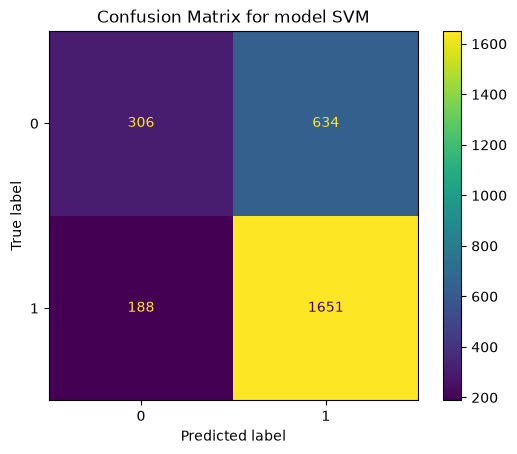

----------------------------------------------------


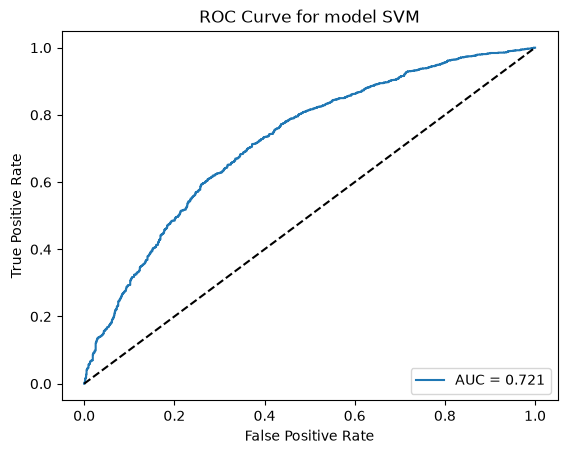

Accuracy: 0.7042101475350846
Precision: 0.7225382932166302
Recall: 0.8977705274605764
F1-Score: 0.8006789524733269
AUC: 0.7214767507780593


In [50]:
# Validação do Modelo
acc, prec, rec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'SVM')
result.loc[0] = ['SVM', acc, prec, rec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

#### SVM com otimização de hiperparâmetros

Em seguida, utilizou-se RandomizedSearchCV por se utilizar de um modelo mais custoso. Dessa forma, espera-se que a classficação seja otimizada, pois ela foi utilizado dentro de um leque de parâmetros oferecidos pela documentação do projeto.

(Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


In [51]:
from sklearn.svm import SVC
from scipy.stats import loguniform

def build_search_svm():
    """Reconstrói o pipeline (StandardScaler + SVC) e a busca de
    hiperparâmetros do SVM, exatamente como documentado na monografia, para
    ser treinado do zero em cada fold (ou com 100% dos dados, no treino
    final do modelo de produção)."""
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(random_state=42, cache_size=1000, max_iter=100000))
    ])

    # Espaço de Busca (prefixo 'svc__' para parâmetros do SVC dentro do pipeline)
    param_dist = {
        'svc__C':      loguniform(1e-2, 1e2),           # potência: [0.01, 100]
        'svc__kernel': ['rbf'],
        'svc__gamma':  ['scale', 'auto'],               # ignorado pelo kernel linear
    }

    return RandomizedSearchCV(
        estimator           = pipe_svm,
        param_distributions = param_dist,
        n_iter              = 40,     # Número de combinações testadas
        cv                  = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros
        scoring             = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit               = 'accuracy',
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['SVM (otimizado)'] = run_cv_search(build_search_svm, X, y, 'SVM (otimizado)')


[SVM (otimizado)] Fold 1/5 -> Acc: 0.692 | Prec: 0.694 | Rec: 0.958 | F1: 0.804 | AUC: 0.706
[SVM (otimizado)] Fold 2/5 -> Acc: 0.686 | Prec: 0.691 | Rec: 0.949 | F1: 0.800 | AUC: 0.703
[SVM (otimizado)] Fold 3/5 -> Acc: 0.705 | Prec: 0.703 | Rec: 0.959 | F1: 0.812 | AUC: 0.735
[SVM (otimizado)] Fold 4/5 -> Acc: 0.688 | Prec: 0.693 | Rec: 0.947 | F1: 0.800 | AUC: 0.720
[SVM (otimizado)] Fold 5/5 -> Acc: 0.691 | Prec: 0.695 | Rec: 0.950 | F1: 0.803 | AUC: 0.706


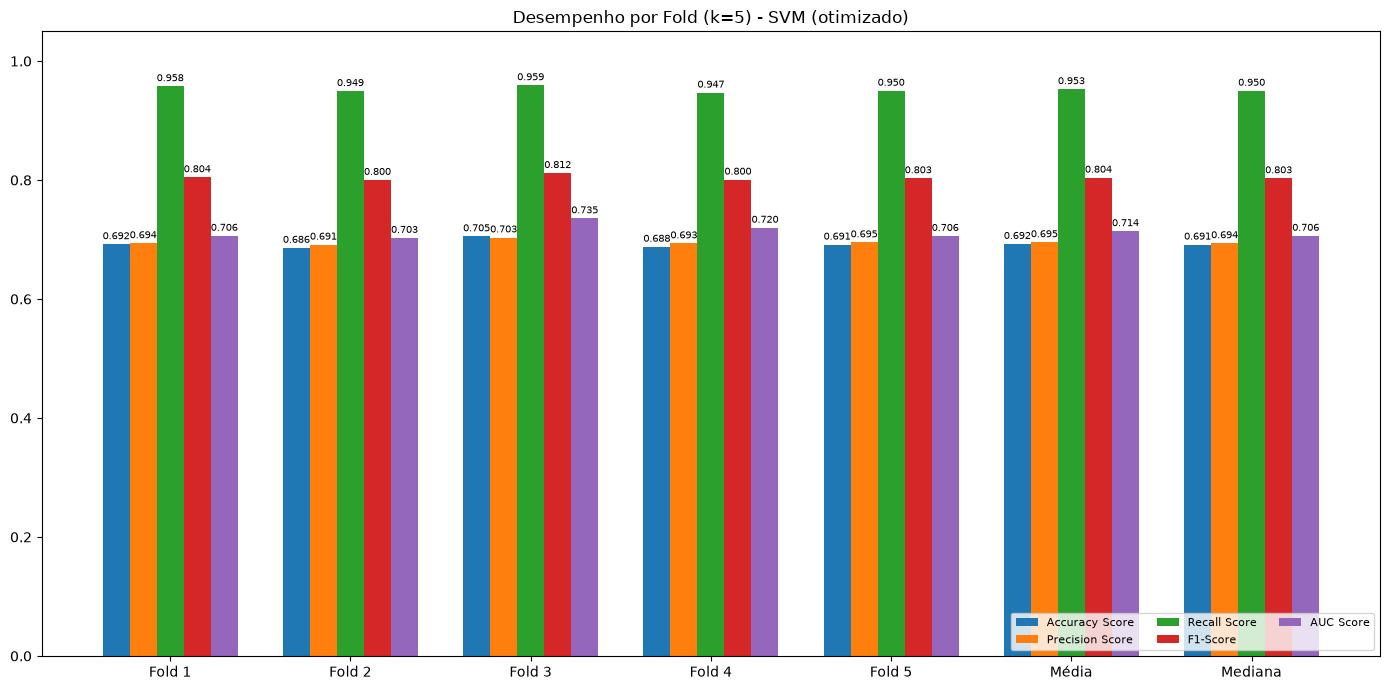

Melhores hiperparâmetros (treino final, 100% dos dados): {'svc__C': np.float64(0.1653693718282443), 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

Modelo salvo em 'models/modelo_svm.pkl'


In [52]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('SVM (otimizado)', cv_metrics['SVM (otimizado)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_svm = build_search_svm()
final_search_svm.fit(X, y)
best_svm = final_search_svm.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_svm.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_svm.pkl'
dump(best_svm, nome)
print(f"\nModelo salvo em '{nome}'")


### 3.2 Decision Trees (Árvores de Decisão)

Assim como no método KNN, a árvore de decisão foi escolhido para esta tarefa com fins de comparação ao artigo base, bem como à sua simplicidade e interpretabilidade. As árvores de decisão são amplamente utilizadas em problemas de aprendizado supervisionado, pois oferecem uma forma clara de visualizar o processo de tomada de decisão do modelo. Elas funcionam dividindo recursivamente o espaço de características em regiões que maximizam a separação das classes (tendo em vista os métodos de avaliação de divisão), criando um modelo fácil de interpretar que pode lidar tanto com variáveis categóricas quanto contínuas.

Os dois métodos para avaliação de divisão das classes são:

* Gini: Mede a impureza de um nó. Um nó é puro se todas as amostras pertencem à mesma classe.
* Entropia (ou ganho de informação): Mede a quantidade de desordem ou imprevisibilidade em um nó

In [53]:
from sklearn.tree import DecisionTreeClassifier

def build_search_dt():
    """Reconstrói o pipeline e a busca de hiperparâmetros (GridSearchCV) da
    Árvore de Decisão, exatamente como documentado na monografia."""
    pipe_DT = Pipeline([
        # ('scaler', MinMaxScaler()),   # opcional para DecisionTree
        ('dt', DecisionTreeClassifier(random_state=42))
    ])

    # Espaço de Busca (prefixo 'dt__' para parâmetros da DT dentro do pipeline)
    hyperparameters_DT = {
        'dt__max_depth': [None] + list(range(1, 11)),        # None ou profundidades de 1 a 10
        'dt__min_samples_split': [2, 5, 10],                 # valores típicos
        'dt__min_samples_leaf': [1, 2, 4],                   # valores típicos
        'dt__criterion': ['gini', 'entropy']
    }

    return GridSearchCV(
        estimator    = pipe_DT,
        param_grid   = hyperparameters_DT,
        cv           = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros
        scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit        = 'accuracy',
        n_jobs       = -1,
        verbose      = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['DT (otimizada)'] = run_cv_search(build_search_dt, X, y, 'DT (otimizada)')


[DT (otimizada)] Fold 1/5 -> Acc: 0.676 | Prec: 0.702 | Rec: 0.887 | F1: 0.784 | AUC: 0.625
[DT (otimizada)] Fold 2/5 -> Acc: 0.662 | Prec: 0.662 | Rec: 1.000 | F1: 0.796 | AUC: 0.594
[DT (otimizada)] Fold 3/5 -> Acc: 0.684 | Prec: 0.705 | Rec: 0.898 | F1: 0.790 | AUC: 0.645
[DT (otimizada)] Fold 4/5 -> Acc: 0.675 | Prec: 0.682 | Rec: 0.953 | F1: 0.795 | AUC: 0.643
[DT (otimizada)] Fold 5/5 -> Acc: 0.661 | Prec: 0.661 | Rec: 1.000 | F1: 0.796 | AUC: 0.583


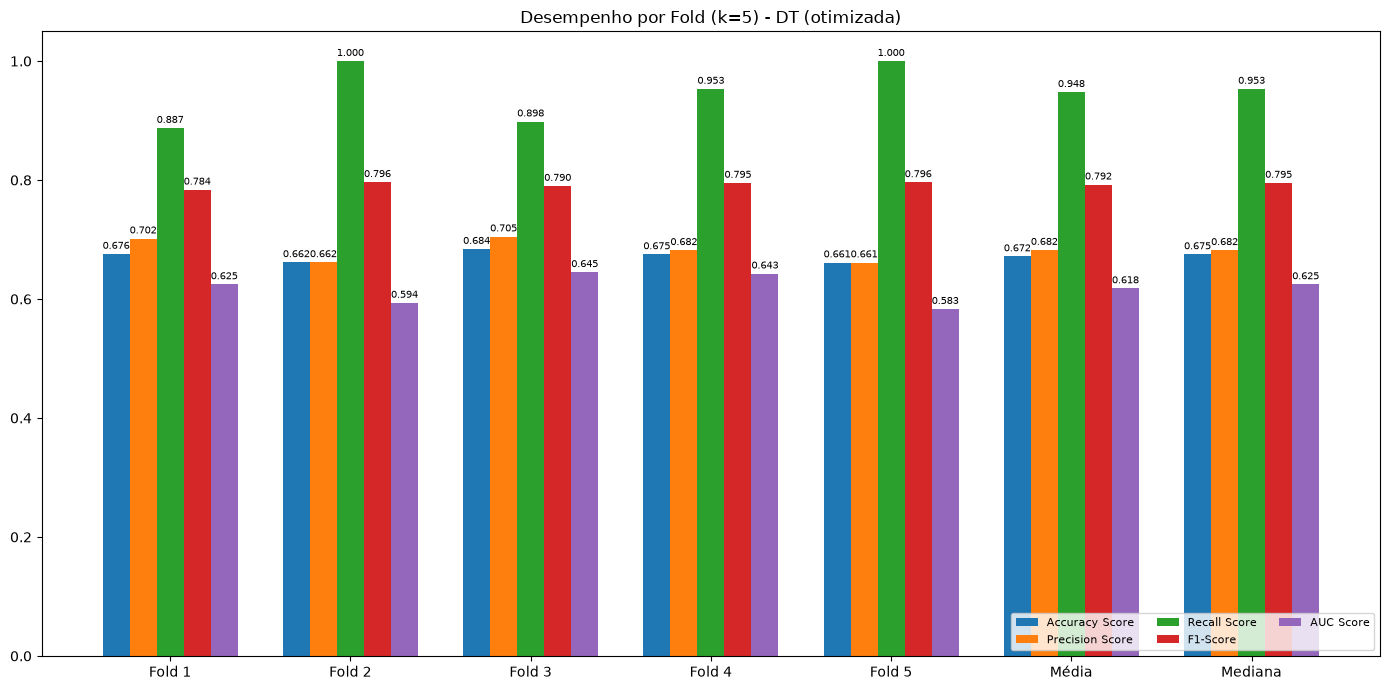

Melhores hiperparâmetros (treino final, 100% dos dados): {'dt__criterion': 'gini', 'dt__max_depth': 1, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}

Modelo salvo em 'models/modelo_DT.pkl'


In [54]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('DT (otimizada)', cv_metrics['DT (otimizada)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_dt = build_search_dt()
final_search_dt.fit(X, y)
best_estimator = final_search_dt.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_dt.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_DT.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")


### 3.3 Random Forests

O modelo Random Forest também foi selecionado para uso. Seguindo o uso de algoritmos que utilizam árvores de decisão, o RandomForestClassifier do scikit-learn baseia-se em árvores independentes treinadas em amostras aleatórias, capturando diferentes aspectos dos dados e reduzindo os efeitos de variância através do processo de agregação. Devido à tal natureza do método, ele é menos suscetível a overfitting em comparação com uma única árvore de decisão.

Fora isso, outro motivo que levou à escolha de seu uso foram pela possibilidade de capturar relações não lineares nos dados, tornando-a adequada para o caso das relações entre variáveis não serem simplesmente lineares e não estar claro quais são os atributos mais relevantes. Por fim, as random forest também são consideradas escolhas sólidas para conjuntos de dados de tamanho moderado, como é o caso.

Para encontrar as melhores combinações de hiperparâmetros, foi novamente utilizado o RandomizedSearchCV, explicado previamente.

In [55]:
from sklearn.ensemble import RandomForestClassifier

def build_search_rf():
    """Reconstrói o pipeline e a busca de hiperparâmetros (GridSearchCV) da
    Random Forest, exatamente como documentado na monografia."""
    pipe_RF = Pipeline([
        # ('scaler', MinMaxScaler()),   # opcional para algoritmos baseados em árvores
        ('rf', RandomForestClassifier(random_state=42))
    ])

    # Espaço de Busca (prefixo 'rf__' para parâmetros da RF dentro do pipeline)
    hyperparameters_RF = {
        'rf__max_depth': [None, 10, 20, 30, 40, 50],
        'rf__min_samples_split': [2, 5, 10],                 # valores típicos
        'rf__min_samples_leaf': [1, 2, 4],                   # valores típicos
        'rf__criterion': ['gini', 'entropy'],
        'rf__max_features': ['sqrt', 'log2']
    }

    return GridSearchCV(
        estimator    = pipe_RF,
        param_grid   = hyperparameters_RF,
        cv           = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros
        scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit        = 'accuracy',
        n_jobs       = -1,
        verbose      = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['RF (otimizada)'] = run_cv_search(build_search_rf, X, y, 'RF (otimizada)')


[RF (otimizada)] Fold 1/5 -> Acc: 0.711 | Prec: 0.718 | Rec: 0.928 | F1: 0.809 | AUC: 0.727
[RF (otimizada)] Fold 2/5 -> Acc: 0.702 | Prec: 0.712 | Rec: 0.923 | F1: 0.804 | AUC: 0.718
[RF (otimizada)] Fold 3/5 -> Acc: 0.731 | Prec: 0.734 | Rec: 0.931 | F1: 0.821 | AUC: 0.756
[RF (otimizada)] Fold 4/5 -> Acc: 0.712 | Prec: 0.724 | Rec: 0.912 | F1: 0.807 | AUC: 0.741
[RF (otimizada)] Fold 5/5 -> Acc: 0.711 | Prec: 0.719 | Rec: 0.924 | F1: 0.809 | AUC: 0.721


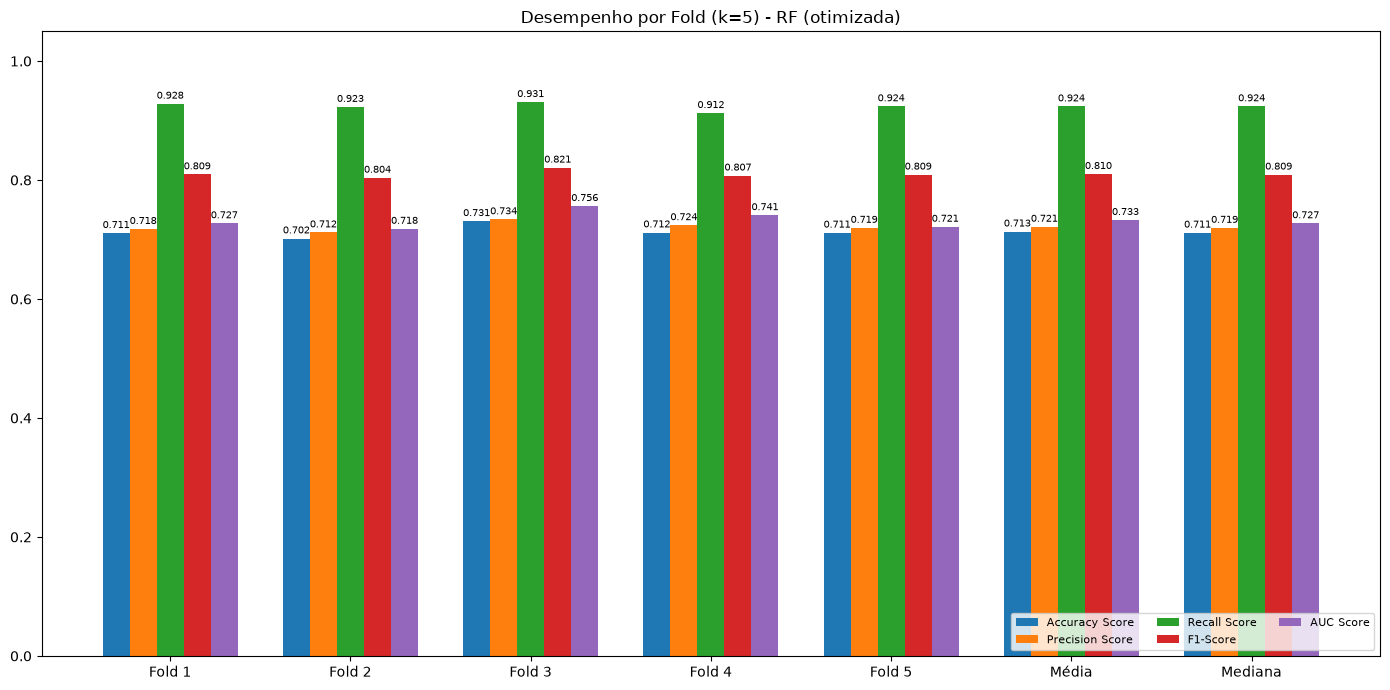

Melhores hiperparâmetros (treino final, 100% dos dados): {'rf__criterion': 'entropy', 'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5}

Modelo salvo em 'models/modelo_RF.pkl'


In [56]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('RF (otimizada)', cv_metrics['RF (otimizada)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_rf = build_search_rf()
final_search_rf.fit(X, y)
best_estimator = final_search_rf.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_rf.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_RF.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")


### 3.4. XGBoost (Extreme Gradient Boosting)

O modelo xgboost foi escolhido para ser usado uma vez que é sabido de seu potencial em problemas de aprendizado supervisionado como classificação, em que seu desempenho se mostra melhor que outros modelos em muitos casos. Isso se deve ao boosting do modelo, que consiste na combinação de diversos modelos preditivos "fracos", sendo esses árvores de decisão, para construção de um modelo único preditivo forte.

Na aplicação demonstrada abaixo, conforme consulta das respectivas documentações do sklearn e do xgboost, usou-se o GridSearchCV para iterar sobre todas combinações possíveis de hiperparâmetros selecionados a partir de uma lista de valores possíveis escolhidos previamente. Para se ter melhor confiabilidade no resultado que determina o melhor modelo dentre as combinações geradas, usou-se cross-validation com 5 folds. O processo descrito é útil para refinar o modelo escolhendo hiperparâmetros que potencializem seu desempenho, ao custo de relativo alto custo computacional para teste de todas combinações possíveis

In [57]:
from xgboost import XGBClassifier

def build_search_xgb():
    """Reconstrói o pipeline e a busca de hiperparâmetros (GridSearchCV) do
    XGBoost, exatamente como documentado na monografia (inclusive o cv=3
    interno, já utilizado originalmente para este modelo)."""
    pipe_xgb = Pipeline([
        # ('scaler', MinMaxScaler()),   # opcional para algoritmos baseados em árvores
        ('xgb', XGBClassifier(random_state=42))                                                                                
    ])

    # Espaço de Busca (prefixo 'xgb__' para parâmetros do XGB dentro do pipeline)
    hyperparameters_xgb = {
        'xgb__n_estimators': [100, 300],            # Número de Árvores
        'xgb__max_depth': [3, 5, 7, 9],             # Profundidade Máxima de cada Árvore
        'xgb__learning_rate': [0.01, 0.05, 0.1],    # Taxa de aprendizado
        'xgb__subsample': [0.7, 0.9],               # Fração de amostras usadas por árvore
        'xgb__colsample_bytree': [0.7, 0.9],        # Fração de colunas (features) amostradas por árvore
        'xgb__min_child_weight': [1, 3, 5],         # peso mínimo de instâncias numa folha
    }

    return GridSearchCV(
        estimator    = pipe_xgb,
        param_grid   = hyperparameters_xgb,
        cv           = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros (mantido em 3)
        scoring      = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit        = 'accuracy',
        n_jobs       = -1,
        verbose      = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['XGBoost (otimizado)'] = run_cv_search(build_search_xgb, X, y, 'XGBoost (otimizado)')


[XGBoost (otimizado)] Fold 1/5 -> Acc: 0.697 | Prec: 0.694 | Rec: 0.971 | F1: 0.809 | AUC: 0.743
[XGBoost (otimizado)] Fold 2/5 -> Acc: 0.688 | Prec: 0.696 | Rec: 0.938 | F1: 0.799 | AUC: 0.701
[XGBoost (otimizado)] Fold 3/5 -> Acc: 0.696 | Prec: 0.696 | Rec: 0.959 | F1: 0.807 | AUC: 0.731
[XGBoost (otimizado)] Fold 4/5 -> Acc: 0.691 | Prec: 0.696 | Rec: 0.944 | F1: 0.801 | AUC: 0.712
[XGBoost (otimizado)] Fold 5/5 -> Acc: 0.690 | Prec: 0.698 | Rec: 0.938 | F1: 0.800 | AUC: 0.705


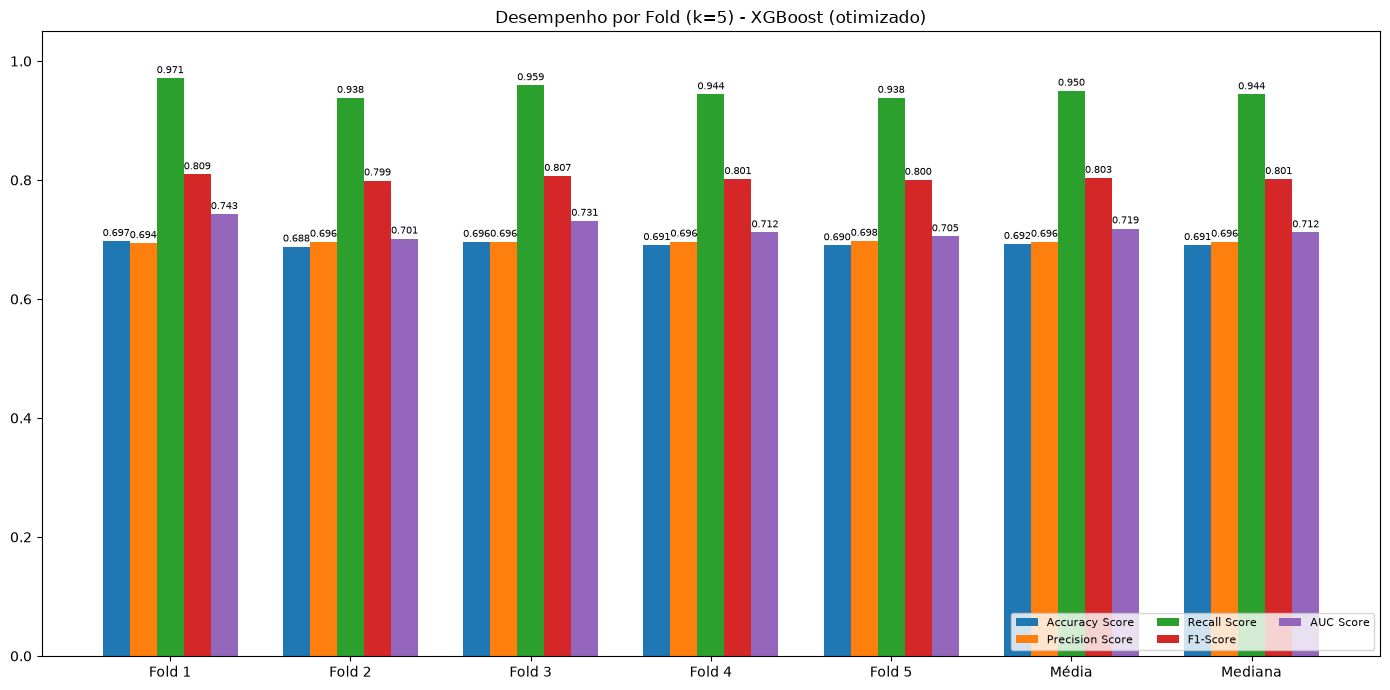

Melhores hiperparâmetros (treino final, 100% dos dados): {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__min_child_weight': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 0.7}

Modelo salvo em 'models/modelo_xgboost.pkl'


In [58]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('XGBoost (otimizado)', cv_metrics['XGBoost (otimizado)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_xgb = build_search_xgb()
final_search_xgb.fit(X, y)
best_estimator = final_search_xgb.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_xgb.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_xgboost.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")


### 3.5. k-Nearest Neighbors (KNN)

O KNN também foi utilizado como base de comparação para os demais métodos aplicados, tendo em vista que este se trata de um dos métodos mais simples e intuitivos para tarefas de classificação. 

Esse algortimo utiliza as distâncias entre as amostras: 
1. para uma nova amostra, o algoritmo calcula a distância euclidiana entre a amostra e todos os pontos de dados no conjunto de treinamento; 
2. com base nas distâncias calculadas, seleciona os K pontos de dados mais próximos;
3. A nova amostra é classificada pela maioria dos rótulos dos K vizinhos mais próximos.

In [59]:
from sklearn.neighbors import KNeighborsClassifier

def build_search_knn():
    """Reconstrói o pipeline e a busca de hiperparâmetros (GridSearchCV) do
    KNN, exatamente como documentado na monografia."""
    pipe_KNN = Pipeline([
        ('scaler', MinMaxScaler()),   # Poderia ser o Standard também
        ('knn', KNeighborsClassifier())
    ])

    # Espaço de Busca (prefixo 'knn__' para parâmetros do KNN dentro do pipeline)
    hyperparameters_KNN = {
        'knn__n_neighbors': list(range(1,20,2)),      # número de vizinhos
        'knn__weights': ['distance'],                 # ponderação das distâncias
        'knn__algorithm': ['auto'],
        'knn__leaf_size': [20, 30, 40],            # afeta construção das árvores (kd/ball)
        'knn__p': [1, 2]                           # 1 = Manhattan, 2 = Euclidiana
    }

    return GridSearchCV(
        estimator     = pipe_KNN,
        param_grid    = hyperparameters_KNN,
        cv            = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros
    scoring           = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit         = 'accuracy',
        n_jobs        = -1,
        verbose       = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['KNN (otimizado)'] = run_cv_search(build_search_knn, X, y, 'KNN (otimizado)')

[KNN (otimizado)] Fold 1/5 -> Acc: 0.697 | Prec: 0.757 | Rec: 0.799 | F1: 0.777 | AUC: 0.730
[KNN (otimizado)] Fold 2/5 -> Acc: 0.703 | Prec: 0.761 | Rec: 0.805 | F1: 0.782 | AUC: 0.728
[KNN (otimizado)] Fold 3/5 -> Acc: 0.716 | Prec: 0.763 | Rec: 0.827 | F1: 0.794 | AUC: 0.751
[KNN (otimizado)] Fold 4/5 -> Acc: 0.701 | Prec: 0.754 | Rec: 0.815 | F1: 0.783 | AUC: 0.742
[KNN (otimizado)] Fold 5/5 -> Acc: 0.702 | Prec: 0.757 | Rec: 0.810 | F1: 0.783 | AUC: 0.728


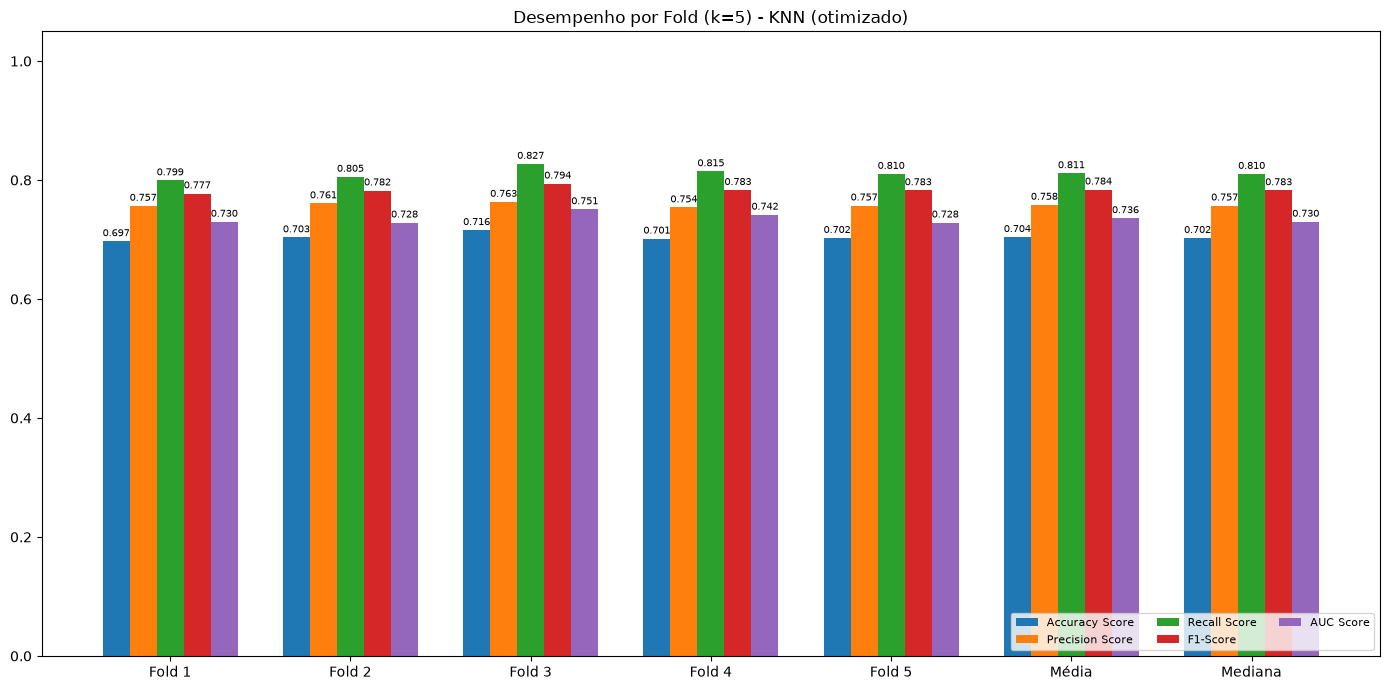

Melhores hiperparâmetros (treino final, 100% dos dados): {'knn__algorithm': 'auto', 'knn__leaf_size': 20, 'knn__n_neighbors': 19, 'knn__p': 2, 'knn__weights': 'distance'}

Modelo salvo em 'models/modelo_knn.pkl'


In [60]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('KNN (otimizado)', cv_metrics['KNN (otimizado)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_knn = build_search_knn()
final_search_knn.fit(X, y)
best_estimator = final_search_knn.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_knn.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_knn.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

### 3.6. Naive Byes

O Naive Bayes também foi utilizado como base de comparação para os demais métodos aplicados, tendo em vista que este se trata de um dos algoritmos mais simples e eficientes computacionalmente para tarefas de classificação, especialmente em problemas envolvendo dados categóricos com grande volume de amostras.

Esse algoritmo utiliza o Teorema de Bayes aliado à suposição de independência entre os atributos:

1. Para uma nova amostra, o algoritmo calcula a probabilidade de cada classe, considerando a frequência dos atributos observados no conjunto de treinamento;
2. Essas probabilidades são obtidas a partir da relação entre a probabilidade a priori da classe e a probabilidade condicional dos atributos dado cada classe;
3. A nova amostra é classificada pela classe que apresenta a maior probabilidade posterior.

No processo de ajuste, o GridSearchCV foi empregado para selecionar os melhores parâmetros do modelo, garantindo maior robustez na comparação com os demais métodos aplicados.

In [61]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

def build_search_nb():
    """Reconstrói o pipeline e a busca de hiperparâmetros (GridSearchCV) do
    Naive Bayes, exatamente como documentado na monografia."""
    # Observação: GaussianNB assume distribuição normal dos atributos contínuos.
    pipe_NB = Pipeline([
        ('scaler', MinMaxScaler()),
        ('nb', GaussianNB())
    ])

    # var_smoothing: fração da maior variância das features adicionada a todas as
    # variâncias (suavização gaussiana). Avaliamos 14 valores em escala logarítmica
    # de 1e-12 a 1e0.
    hyperparameters_NB = {
        'nb__var_smoothing': np.logspace(-12, 0, 14)
    }

    return GridSearchCV(
        estimator  = pipe_NB,
        param_grid = hyperparameters_NB,
        cv         = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros
        scoring    = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit      = 'accuracy',
        n_jobs     = -1,
        verbose    = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['NB (otimizado)'] = run_cv_search(build_search_nb, X, y, 'NB (otimizado)')

[NB (otimizado)] Fold 1/5 -> Acc: 0.662 | Prec: 0.662 | Rec: 0.999 | F1: 0.796 | AUC: 0.627
[NB (otimizado)] Fold 2/5 -> Acc: 0.662 | Prec: 0.662 | Rec: 1.000 | F1: 0.796 | AUC: 0.646
[NB (otimizado)] Fold 3/5 -> Acc: 0.663 | Prec: 0.662 | Rec: 1.000 | F1: 0.797 | AUC: 0.674
[NB (otimizado)] Fold 4/5 -> Acc: 0.661 | Prec: 0.662 | Rec: 0.999 | F1: 0.796 | AUC: 0.645
[NB (otimizado)] Fold 5/5 -> Acc: 0.661 | Prec: 0.661 | Rec: 1.000 | F1: 0.796 | AUC: 0.637


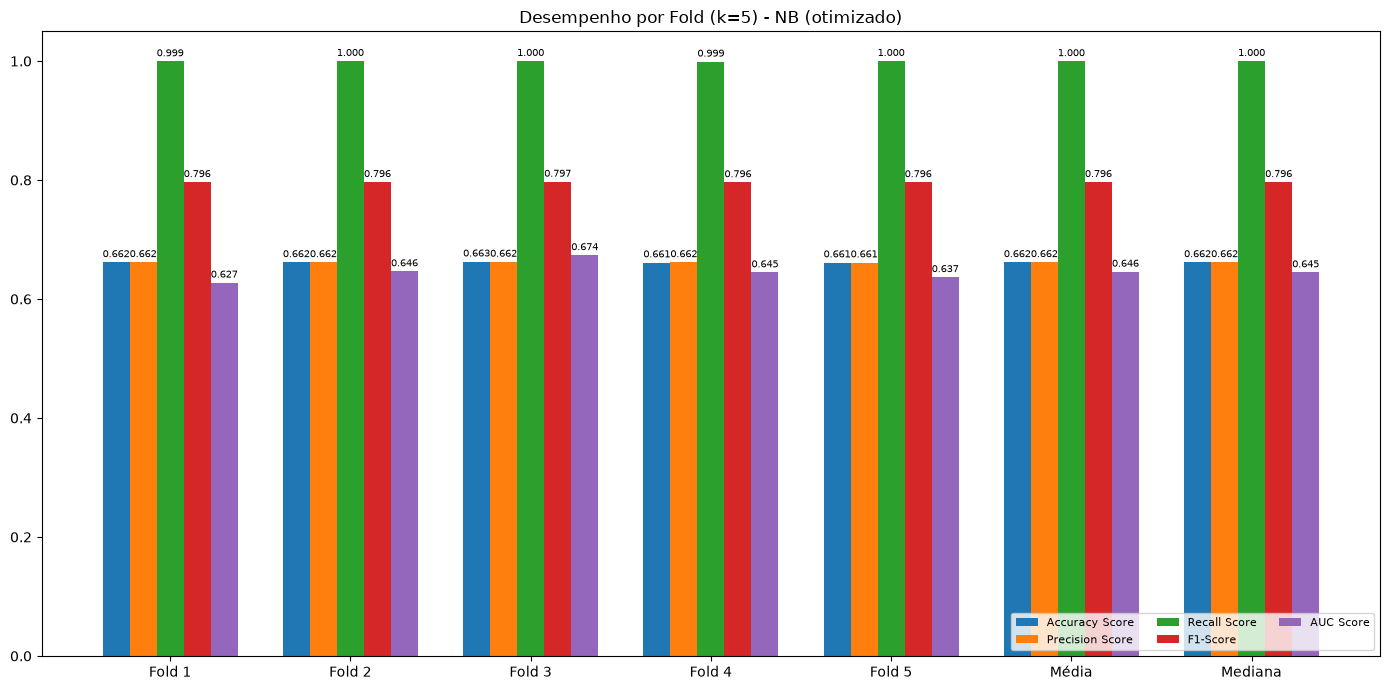

Melhores hiperparâmetros (treino final, 100% dos dados): {'nb__var_smoothing': np.float64(1.0)}

Modelo salvo em 'models/modelo_NB.pkl'


In [62]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('NB (otimizado)', cv_metrics['NB (otimizado)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_nb = build_search_nb()
final_search_nb.fit(X, y)
best_estimator = final_search_nb.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_nb.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_NB.pkl'
dump(best_estimator, nome)
print(f"\nModelo salvo em '{nome}'")

### 3.7. MLP (Multilayer Perceptron)

Por fim, o MLP (Multilayer Perceptron) Classifier foi escolhido, pois ele é um tipo de rede neural artificial composta por várias camadas de neurônios interconectados, que é capaz de aprender relações complexas entre entradas e saídas por meio de treinamento supervisionado. Ele utiliza funções de ativação não lineares, permitindo modelar problemas que não podem ser resolvidos por métodos lineares simples. Dessa forma, deve-se utilizá-lo porque consegue generalizar bem em tarefas diversas e lidar com dados de alta dimensionalidade - o que se encaixa no nosso caso.

Ademais, foi utilizado o RandomizedSearchCV nesse caso, pois o espaço de busca do MLP é muito maior que o dos outros modelos, especialmente por causa de hidden_layer_sizes (cada arquitetura é uma combinação diferente). Além disso, alpha e learning_rate_init são naturalmente contínuos — o RandomizedSearchCV permite amostrá-los com loguniform, o que o GridSearchCV não suporta diretamente. Um Grid exaustivo aqui geraria centenas/milhares de combinações. 

In [63]:
from sklearn.neural_network import MLPClassifier

def build_search_mlp():
    """Reconstrói o pipeline e a busca de hiperparâmetros (RandomizedSearchCV)
    do MLP, exatamente como documentado na monografia."""
    # MLP é sensível à escala dos dados; StandardScaler é obrigatório para
    # garantir convergência estável do gradiente.
    pipe_mlp = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            random_state=42,
            max_iter=500,          # aumentado (300 -> 500) para garantir convergência
                                   # em arquiteturas mais profundas
            early_stopping=True,   # interrompe se a validação interna não melhora
            n_iter_no_change=20,   # paciência aumentada (15 -> 20) para sair de platôs
            validation_fraction=0.1
        ))
    ])

    # Espaço de Busca
    #   hidden_layer_sizes : arquitetura da rede (redes de até 4 camadas e até
    #                        512 neurônios).
    #   activation         : 'relu' costuma ser mais estável; 'tanh' às vezes
    #                        supera em datasets de tamanho médio.
    #   alpha              : regularização L2 (faixa 1e-5 a 1e0).
    #   learning_rate_init : taxa de aprendizado inicial (faixa 1e-4 a 5e-2).
    #   learning_rate      : 'adaptive' reduz a taxa quando a perda de treino estagna.
    param_dist_mlp = {
        'mlp__hidden_layer_sizes': [
            (64, 32),
            (128, 64),
            (128, 64, 32),
            (256, 128, 64),
            (256, 128),
        ],
        'mlp__activation'         : ['relu', 'tanh'],
        'mlp__alpha'              : loguniform(1e-5, 1e0),
        'mlp__learning_rate_init' : loguniform(1e-4, 1e-2),
        'mlp__learning_rate'      : ['constant', 'adaptive'],
    }

    return RandomizedSearchCV(
        estimator           = pipe_mlp,
        param_distributions = param_dist_mlp,
        n_iter              = 50,    # combinações testadas
        cv                  = 3,      # Folds usados no CV interno p/ otimização de hiperparâmetros
        scoring             = {'accuracy':'accuracy', 'roc_auc':'roc_auc', 'recall':'recall'},
        refit               = 'accuracy',
        n_jobs              = 8,
        random_state        = 42,
        verbose             = 0       # reduzido para não poluir a saída ao longo dos 5 folds externos
    )

# --- Validação cruzada externa (k=5) ---
cv_metrics['MLP (otimizado)'] = run_cv_search(build_search_mlp, X, y, 'MLP (otimizado)')


[MLP (otimizado)] Fold 1/5 -> Acc: 0.675 | Prec: 0.705 | Rec: 0.873 | F1: 0.780 | AUC: 0.668
[MLP (otimizado)] Fold 2/5 -> Acc: 0.685 | Prec: 0.714 | Rec: 0.872 | F1: 0.786 | AUC: 0.685
[MLP (otimizado)] Fold 3/5 -> Acc: 0.712 | Prec: 0.735 | Rec: 0.883 | F1: 0.802 | AUC: 0.725
[MLP (otimizado)] Fold 4/5 -> Acc: 0.701 | Prec: 0.722 | Rec: 0.892 | F1: 0.798 | AUC: 0.718
[MLP (otimizado)] Fold 5/5 -> Acc: 0.694 | Prec: 0.731 | Rec: 0.849 | F1: 0.786 | AUC: 0.689


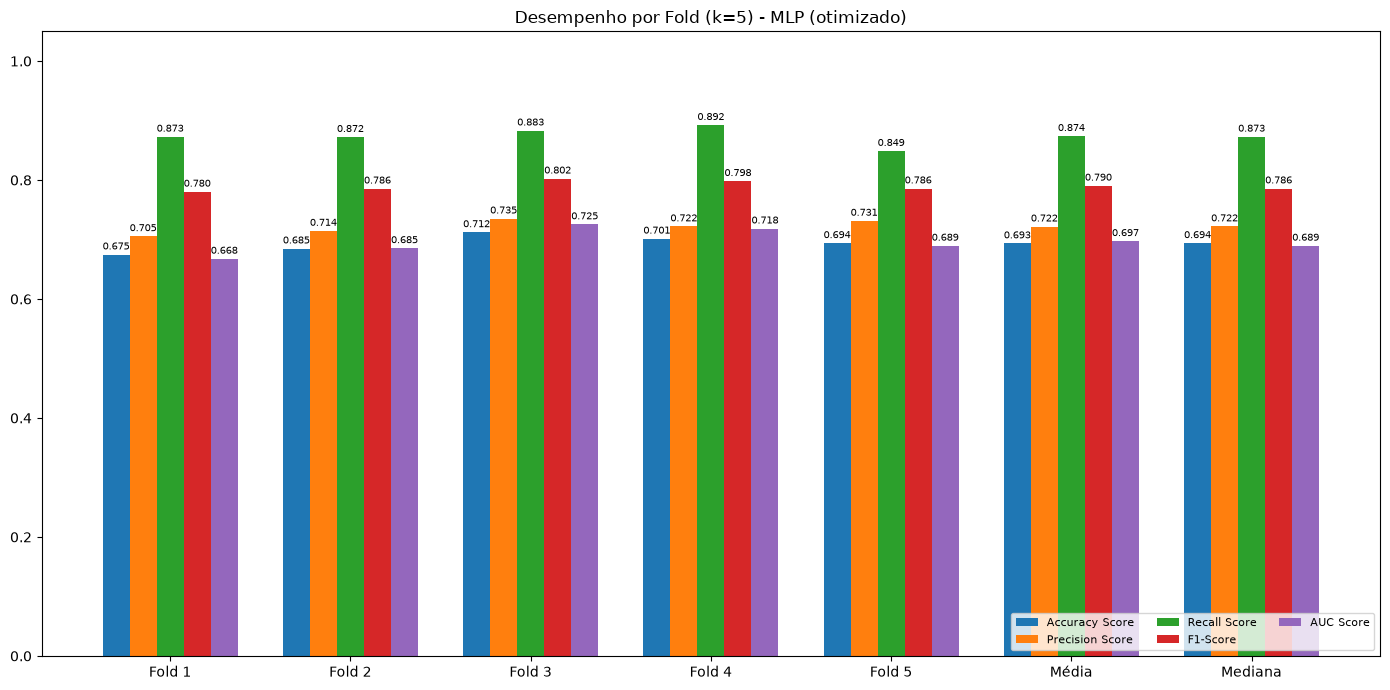

Melhores hiperparâmetros (treino final, 100% dos dados): {'mlp__activation': 'tanh', 'mlp__alpha': np.float64(0.9577860311800289), 'mlp__hidden_layer_sizes': (256, 128, 64), 'mlp__learning_rate': 'constant', 'mlp__learning_rate_init': np.float64(0.006321732490144022)}

Modelo salvo em 'models/modelo_MLP.pkl'


In [64]:
# --- Histograma individual do modelo (5 folds + média + mediana) ---
plot_model_cv_histogram('MLP (otimizado)', cv_metrics['MLP (otimizado)'])

# --- Treino final do modelo de produção, agora com 100% dos dados ---
final_search_mlp = build_search_mlp()
final_search_mlp.fit(X, y)
best_mlp = final_search_mlp.best_estimator_
print("Melhores hiperparâmetros (treino final, 100% dos dados):", final_search_mlp.best_params_)

# --- Salvar modelo de produção ---
nome = 'models/modelo_MLP.pkl'
dump(best_mlp, nome)
print(f"\nModelo salvo em '{nome}'")


### Comparação das Métricas de Desempenho (Validação Cruzada, k=5)

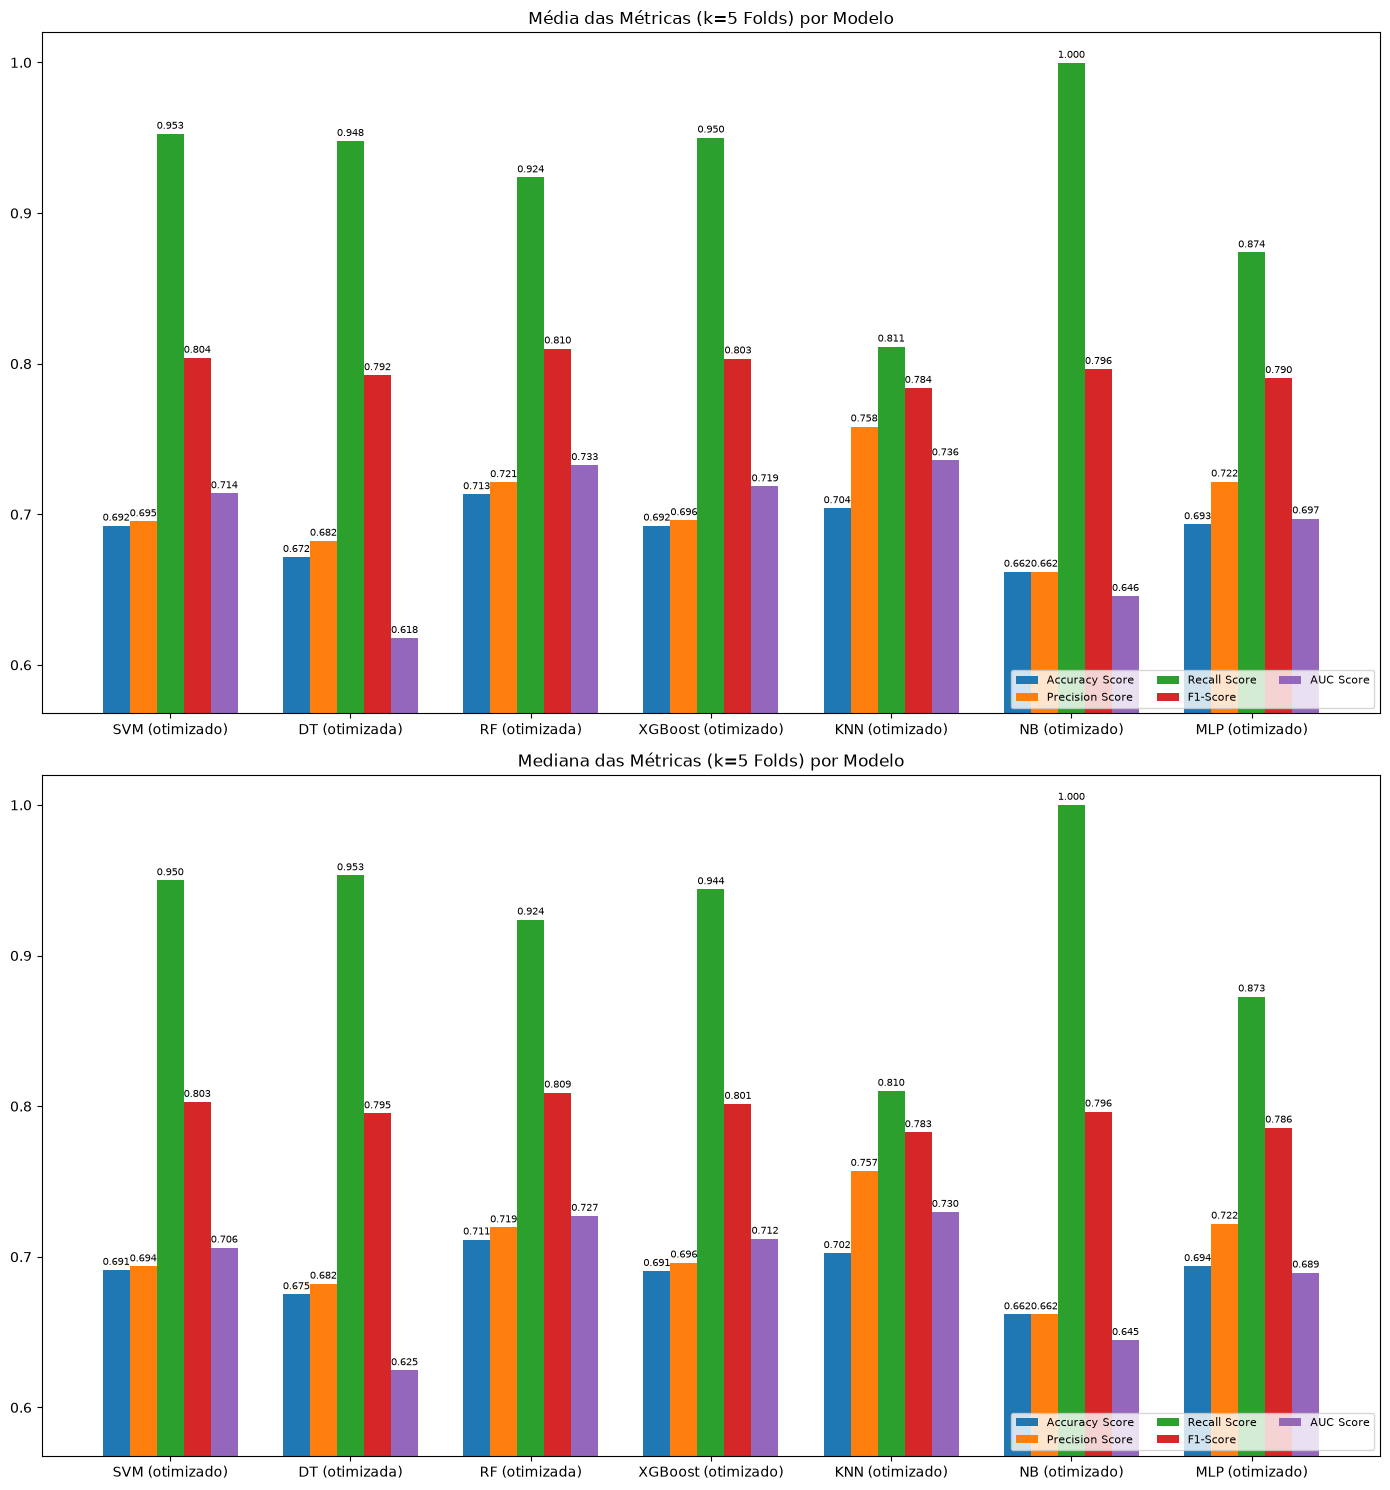

In [65]:
# Histograma final: média e mediana de cada métrica, por modelo, calculadas
# ao longo dos 5 folds da validação cruzada.
modelos_cv = list(cv_metrics.keys())

medias   = {m: [np.mean(cv_metrics[mod][m]) for mod in modelos_cv] for m in METRICAS}
medianas = {m: [np.median(cv_metrics[mod][m]) for mod in modelos_cv] for m in METRICAS}

todos_valores = [v for m in METRICAS for v in medias[m] + medianas[m]]
y_min = max(0.0, min(todos_valores) - 0.05)
y_max = min(1.02, max(todos_valores) + 0.05)

x = np.arange(len(modelos_cv))
width = 0.15

fig, axes = plt.subplots(2, 1, figsize=(14, 15))

# --- Médias entre os 5 folds ---
ax = axes[0]
for i, metrica in enumerate(METRICAS):
    offset = (i - (len(METRICAS) - 1) / 2) * width
    barras = ax.bar(x + offset, medias[metrica], width, label=metrica)
    ax.bar_label(barras, padding=2, fmt='%.3f', fontsize=7)
ax.set_ylim(y_min, y_max)
ax.set_xticks(x)
ax.set_xticklabels(modelos_cv)
ax.set_title('Média das Métricas (k=5 Folds) por Modelo')
ax.legend(loc='lower right', ncol=3, fontsize=8)

# --- Medianas entre os 5 folds ---
ax = axes[1]
for i, metrica in enumerate(METRICAS):
    offset = (i - (len(METRICAS) - 1) / 2) * width
    barras = ax.bar(x + offset, medianas[metrica], width, label=metrica)
    ax.bar_label(barras, padding=2, fmt='%.3f', fontsize=7)
ax.set_ylim(y_min, y_max)
ax.set_xticks(x)
ax.set_xticklabels(modelos_cv)
ax.set_title('Mediana das Métricas (k=5 Folds) por Modelo')
ax.legend(loc='lower right', ncol=3, fontsize=8)

plt.tight_layout()
plt.show()
